/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc
952
0


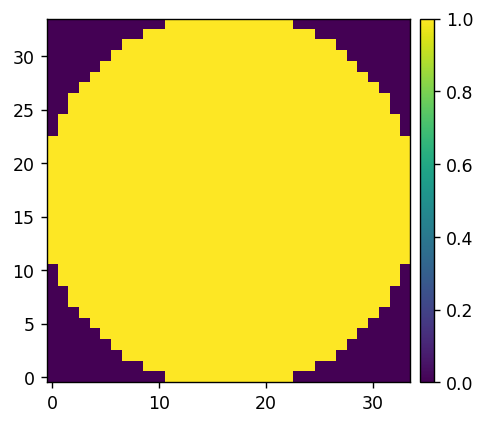

In [6]:
import numpy as np
import astropy.units as u
import threading as th
import time 
from datetime import datetime
today = int(datetime.today().strftime('%Y%m%d'))
from IPython.display import clear_output
from importlib import reload
import copy
import os
from pathlib import Path

cwd = Path(os.getcwd())

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize, CenteredNorm
from matplotlib.patches import Circle, Rectangle

import scoob_llowfsc
print(scoob_llowfsc.path)
data_path = scoob_llowfsc.path/'exp-data'

import scoob_llowfsc.llowfsc as llowfsc
import scoob_llowfsc.scoob_interface as scoobi
import scoob_llowfsc.utils as utils
import scoob_llowfsc.telem as telem
from scoob_llowfsc.math_module import xp, xcipy, ensure_np_array
from scoob_llowfsc.imshows import imshow

from magpyx.utils import ImageStream
import purepyindi
from purepyindi import INDIClient
import purepyindi2
from purepyindi2 import IndiClient

client0 = INDIClient('localhost', 7624)
client0.start()
client = IndiClient()
client.connect()
client.get_properties()

def restart_clients():
    client0 = INDIClient('localhost', 7624)
    client0.start()

    client = IndiClient()
    client.connect()
    client.get_properties()

wavelength = 633e-9

dm_mask = ensure_np_array(scoobi.make_dm_mask())
print(dm_mask.sum())
imshow([dm_mask])


In [9]:
reload(telem)

exp_path = data_path/f'exp-{today}'
llowfsc_data_path = data_path/f'exp-{today}'/'llowfsc'
telem.make_dir(exp_path)
telem.make_dir(llowfsc_data_path)

Directory '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250320' already exists.
Directory '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250320/llowfsc' already exists.


In [11]:
reload(scoobi)
camlo_blacklevel = 100
camlo_gain = 120
camlo_exp_time = .1e-3

scoobi.set_camlo_blacklevel(camlo_blacklevel, client0)
scoobi.set_camlo_gain(camlo_gain, client0)
scoobi.set_camlo_exp_time(camlo_exp_time, client0)

Set CAMLO blacklevel.
Set the CAMLO gain setting to 120.0
Set the CAMLO exposure time to 1.00e-04s


# Initialize streams and create required shmims.

In [12]:
camlo_stream = ImageStream('camnsv')
camlo_dims = camlo_stream.shape

camlo_ref_channel = 'camlo_ref_0'
camlo_ref_delta_channel = 'camlo_ref_offset'

scoobi.create_shmim(camlo_ref_channel, camlo_dims)
scoobi.create_shmim(camlo_ref_delta_channel, camlo_dims)

camlo_ref_stream = ImageStream(camlo_ref_channel)
camlo_ref_offset_stream = ImageStream(camlo_ref_delta_channel)

dm_lo_channel = 'dm00disp02'
dm_dh_channel = 'dm00disp03'
dm_lo_stream = ImageStream(dm_lo_channel)
dm_dh_stream = ImageStream(dm_dh_channel)

INFO:utils:Got semaphore index 0.


0


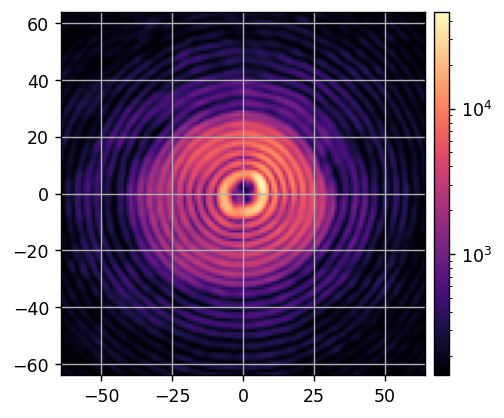

In [13]:
ref_im = np.mean( camlo_stream.grab_many(200), axis=0)
imshow([ref_im], grids=[1], pxscls=[1], norms=[LogNorm()], cmaps=['magma'])

In [ ]:
irad = 3
orad = 35
control_mask = llowfsc.create_control_mask(camlo_dims, irad, orad, even=1)
# control_mask = xp.ones((M.nlocam, M.nlocam)).astype(bool)
imshow2(control_mask, ref_im * control_mask, grid=True, pxscl=1, lognorm2=True, vmin2=1e1)

In [ ]:
camlo_ref_channel.write(ref_im)

# Perform LLOWFSC calibration with Hadamard modes.

In [ ]:
had_modes = ensure_np_array(utils.create_hadamard_modes(xp.array(I.dm_mask)))
had_modal_matrix = had_modes.reshape(had_modes.shape[0], -1)
imshow1(had_modes[8])

In [ ]:
reload(llowfsc)
I.zero_dm()

had_calib_amp = 3e-9
had_nframes = 10
had_response_matrix, had_response_cube = llowfsc.calibrate_without_fsm(
    camlo_stream, 
    dm_lo_stream, 
    had_modes, 
    control_mask, 
    amps=had_calib_amp, 
    NFRAMES=had_nframes, 
    dm_delay=0.001, 
    # plot=True,
)


In [ ]:
had_calib_data = {
    'response_matrix':had_response_matrix,
    'response_cube':had_response_cube,
    'modes':had_modes,
    'calib_amp':had_calib_amp,
    'control_mask':control_mask,
    'NLOCAM':I.NLOCAM,
    'camlo_exp_time':camlo_exp_time,
    'camlo_gain':camlo_gain,
    'fiber_atten':fib_atten,
}
utils.save_pickle(llowfsc_data_path/'hadamard_calibration.pkl', had_calib_data)

Saved data to:  ../data/llowfsc+iefc/20241217_llowfsc_had_calib_data.pkl


In [ ]:
had_calib_data = utils.load_pickle(f'../data/llowfsc+iefc/{today}_llowfsc_had_calib_data.pkl')
had_rm = had_calib_data['had_response_matrix']

# Define the process to do dark hole offsetting.

In [ ]:
reload(llowfsc)
llowfsc.update_locam_delta(had_rm, had_modal_matrix, control_mask, dm_dh_stream, camlo_ref_delta_stream,)

In [ ]:
reload(scoobi)
reload(llowfsc)
reload(utils)

update_freq = 100
interval = 1/update_freq

args = [
    had_rm, 
    had_modal_matrix, 
    control_mask, 
    dm_dh_stream, 
    camlo_ref_delta_stream,
]

offset_process = utils.Process(
    interval, 
    llowfsc.update_ref_delta, 
    args, # the args
)

In [ ]:
telem.toggle(1, camlo_ref_delta_channel, client0)
offset_process.start()

In [ ]:
offset_process.cancel()
telem.toggle(1, camlo_ref_delta_channel, client0)

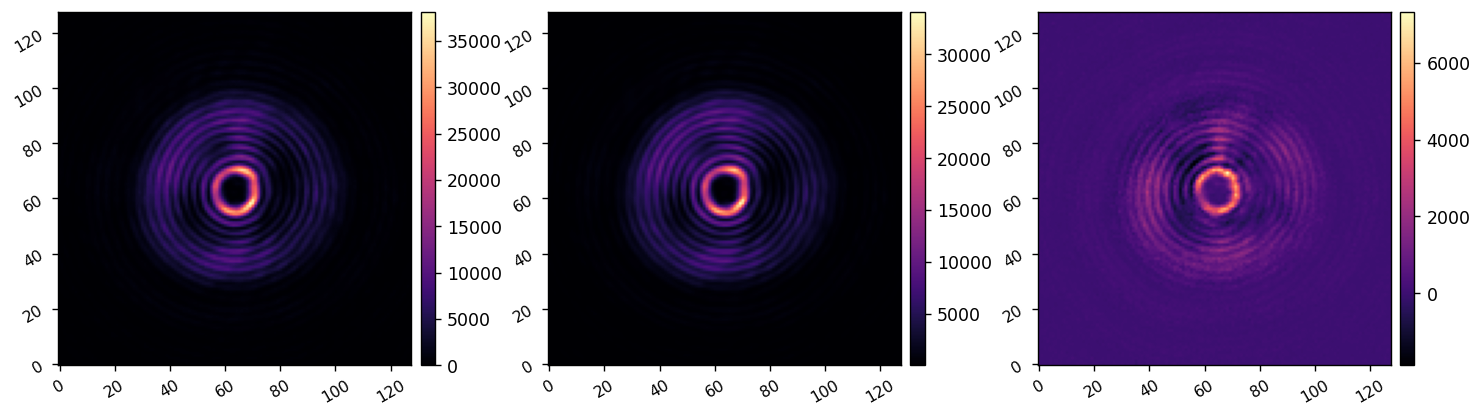

In [ ]:
dm_dh_stream.write(0.00*had_modes[500])
pred = camlo_ref_stream.grab_latest() + camlo_ref_delta_stream.grab_latest()
real = camlo_stream.grab_after()
diff = real - pred
imshow3(real, pred, diff)